In [ ]:
#Submited by: Ryan O. Cuarez
# ===== EXPERIMENT ENVIRONMENT =====
# Python       : 3.12.3
# Python Path  : /home/mis/tf-gpu/bin/python
# TensorFlow   : 2.21.0
# Keras        : 3.15.1
# NumPy        : 2.5.3
# Matplotlib   : 3.11.1
# OpenCV       : 5.0.0
# ===== HARDWARE =====
# GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Loading Dataset and CNN
*Rolando A. Pula*

This notebook is a runnable version of the "Loading Dataset and CNN" slide deck. It walks through:

1. Loading a Dogs vs. Cats image dataset with OpenCV
2. Preprocessing the images (grayscale, resize, shuffle)
3. Saving/loading the prepared data with `pickle`
4. Building and training a Convolutional Neural Network (CNN) with TensorFlow/Keras to classify dogs vs. cats

> **Before you run this notebook:** download the Kaggle "Dogs vs. Cats" dataset (e.g. `https://www.kaggle.com/c/dogs-vs-cats/data` or the mirrored `salader/dogs-vs-cats` dataset on Kaggle) and unzip it so you have two folders, `Dog/` and `Cat/`, each full of `.jpg` images. Then set `DATADIR` below to point at the parent folder that contains `Dog/` and `Cat/`.

## Requirements for Image Processing

- **GPU** (optional, speeds up training but not required)
- **OpenCV** (`cv2`) – for image processing
- **os module** – lets Python interface with the OS running on your computer (already in the standard library)
- **Data** – we'll use the Kaggle "Dogs vs. Cats" dataset

Run the cell below once to install the packages this notebook needs (skip it if they're already installed in your environment).

In [1]:
# Run this once if the packages below aren't already installed.
# %pip install opencv-python numpy matplotlib tensorflow

In [1]:
import sys
print(sys.executable)
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

/home/mis/tf-gpu/bin/python


I0000 00:00:1789624287.370678     425 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:")

for gpu in tf.config.list_physical_devices('GPU'):
    print("  ", gpu)

TensorFlow version: 2.21.0
Built with CUDA: True
GPU devices:
   PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
import tensorflow as tf
import time

with tf.device('/GPU:0'):
    a = tf.random.normal((5000, 5000))
    b = tf.random.normal((5000, 5000))

    start = time.time()
    c = tf.matmul(a, b)
    elapsed = time.time() - start

print("Device used:", c.device)
print(f"Computation time: {elapsed:.3f} seconds")

Device used: /job:localhost/replica:0/task:0/device:GPU:0
Computation time: 0.057 seconds


I0000 00:00:1789624311.281816     425 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6094 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


## Checking and installing OpenCV

The original slides show installing OpenCV through **Anaconda Navigator** (Environments tab → search `opencv` → Install). If you're not using Anaconda, the `pip install opencv-python` command in the cell above does the same thing.

## Calling the Necessary Modules

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

In [58]:
import sys
import tensorflow as tf
import keras
import numpy as np
import matplotlib
import cv2


print("===== EXPERIMENT ENVIRONMENT =====")
print("Python       :", sys.version.split()[0])
print("Python Path  :", sys.executable)
print("TensorFlow   :", tf.__version__)
print("Keras        :", keras.__version__)
print("NumPy        :", np.__version__)
print("Matplotlib   :", matplotlib.__version__)
print("OpenCV       :", cv2.__version__)



print("\n===== HARDWARE =====")
print("GPU:", tf.config.list_physical_devices('GPU'))

===== EXPERIMENT ENVIRONMENT =====
Python       : 3.12.3
Python Path  : /home/mis/tf-gpu/bin/python
TensorFlow   : 2.21.0
Keras        : 3.15.1
NumPy        : 2.5.3
Matplotlib   : 3.11.1
OpenCV       : 5.0.0

===== HARDWARE =====
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Preparation

Set `DATADIR` to the folder on your machine that contains the `Dog` and `Cat` subfolders (this replaces the original slide's hard-coded Windows path, `C:/Users/admin/Desktop/AMEN/Deep_Learning_class/Kaggle_dataset/PetImages`, with something you can edit for your own machine).

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')


## Unzipping the Dataset

Given that the dataset is in a `.zip` file in Google Drive, we need to unzip it to a local directory before processing. I'll unzip `PetImages.zip` to `/content/` and then set `DATADIR` to this new location.

In [7]:
# import zipfile
# import os

# # Path to the zip file in Google Drive

# zip_file_path = '/content/drive/MyDrive/Bioinformatics/PetImages.zip'

# # Destination directory to unzip the files
# destination_dir = '/content/'

# # Create the destination directory if it doesn't exist
# os.makedirs(destination_dir, exist_ok=True)

# # Unzip the file
# with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#     zip_ref.extractall(destination_dir)

# print(f"Unzipped '{zip_file_path}' to '{destination_dir}'")

# # The dataset will be unzipped into a folder named 'PetImages' inside destination_dir
# # Update DATADIR to point to this unzipped location

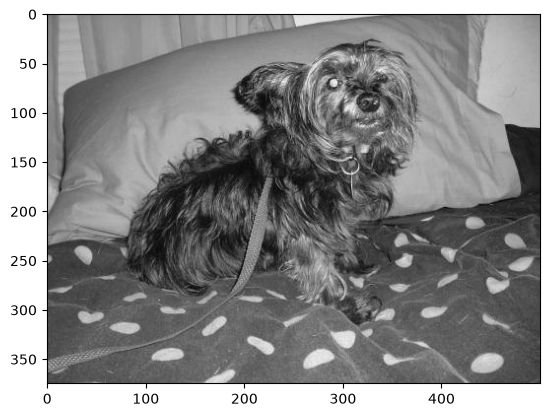

In [5]:
DATADIR = "/mnt/d/DIT/1st Sem/BioInformatics/Activity Sept 9 2026/PetImages"  # <- change this to the path that contains your Dog/ and Cat/ folders
# this is the directory of your datasets
CATEGORIES = ["Dog", "Cat"]   # Defining the label as "Dog" or "Cat"

for category in CATEGORIES:
    path = os.path.join(DATADIR, category)  # path to cats or dogs dir
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        if img_array is None:
            # a handful of files in the Kaggle dataset are corrupted/unreadable - skip them
            continue

        # reading the image in the path and transforming it into an array
        # cv2.IMREAD_GRAYSCALE converts the image to grayscale so the CNN only has
        # to learn from one color channel instead of three (faster, smaller model)

        plt.imshow(img_array, cmap="gray")
        plt.show()
        break
    break

## Image Inspection

In [6]:
print(img_array)          # Displaying the image in array form (just for checking)
print(img_array.shape)    # checking the resolution of the image

[[117 117 119 ... 133 132 132]
 [118 117 119 ... 135 134 134]
 [119 118 120 ... 137 136 136]
 ...
 [ 79  74  73 ...  80  76  73]
 [ 78  72  69 ...  72  73  74]
 [ 74  71  70 ...  75  73  71]]
(375, 500)


## Image Resizing

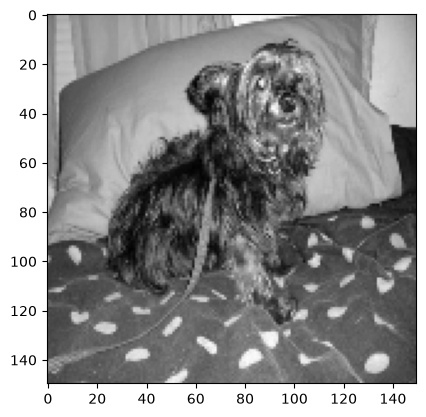

In [27]:
IMG_SIZE = 150  # initializing variable "IMG_SIZE" as 100

new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

## Assigning Training Data

In [28]:
training_data = []  # assigning training data

def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)  # path to cats or dogs dir
        class_num = CATEGORIES.index(category)
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                pass

create_training_data()

Corrupt JPEG data: 399 extraneous bytes before marker 0xd9
Corrupt JPEG data: 226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 254 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2230 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9


## Checking the Number of Training Data

In [29]:
print(len(training_data))

24997


## Randomizing/Shuffling the Data

In [30]:
import random
random.shuffle(training_data)

for sample in training_data[:10]:
    print(sample[1])

0
0
1
1
0
0
1
0
1
0


## Assigning Variables for Features and Labels

In [31]:
X = []  # feature set
y = []  # labels

for features, label in training_data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)  # 1 is for grayscale
y = np.array(y)  # Keras expects the labels as an array too

## Using the Pickle Module

In [32]:
import pickle  # pickle lets you save your training data, avoiding recreating it
                # from scratch every time you want to adjust the model

with open('X.pickle', 'wb') as f:
    pickle.dump(X, f)

with open('y.pickle', 'wb') as g:
    pickle.dump(y, g)

## Using Pickle (Loading It Back)

In [33]:
pickle_in = open('X.pickle', 'rb')
X = pickle.load(pickle_in)

X[1]

array([[[ 22],
        [ 16],
        [ 13],
        ...,
        [ 47],
        [ 47],
        [ 45]],

       [[ 59],
        [ 51],
        [ 36],
        ...,
        [ 47],
        [ 45],
        [ 45]],

       [[ 77],
        [ 74],
        [ 73],
        ...,
        [ 47],
        [ 46],
        [ 46]],

       ...,

       [[ 33],
        [ 35],
        [ 38],
        ...,
        [145],
        [115],
        [115]],

       [[ 32],
        [ 35],
        [ 36],
        ...,
        [136],
        [117],
        [117]],

       [[ 31],
        [ 34],
        [ 34],
        ...,
        [137],
        [124],
        [114]]], shape=(150, 150, 1), dtype=uint8)

## What is a CNN?

**CNN** stands for **Convolutional Neural Network** — a type of neural network especially well suited to image data because it learns spatial patterns (edges, textures, shapes) through convolution and pooling layers instead of treating every pixel independently.

Further reading:
- https://medium.com/data-science-group-iitr/building-a-convolutional-neural-network-in-python-with-tensorflow-d251c3ca8117
- https://hackernoon.com/what-is-a-capsnet-or-capsule-network-2bfbe48769cc

## Using a CNN for Classification of Images

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import pickle

X = pickle.load(open('X.pickle', 'rb'))
y = pickle.load(open('y.pickle', 'rb'))

## Building, Compiling, Training, and Evaluating the CNN

`X = X/255.0` normalizes pixel values from 0-255 to the 0-1 range.

The dataset is split into:
- 80% development data, from which 20% is used as validation during training
- 20% completely unseen test data for final evaluation

This allows the notebook to report Training Accuracy, Validation Accuracy, Test Accuracy, Test Loss, Precision, Recall, and macro-average F1-score without evaluating the model on training data as if it were test data.

In [35]:
# Required imports for dataset splitting and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

# Ensure labels are a NumPy array
y = np.asarray(y).astype(int)

# Split the dataset into training/development data and a completely unseen test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Total samples:      {len(X):,}")
print(f"Training samples:   {len(X_train):,}")
print(f"Test samples:       {len(X_test):,}")
print("\nThe training data will use validation_split=0.20, so the final proportions are approximately:")
print("  Training:   64%")
print("  Validation: 16%")
print("  Test:       20%")

Total samples:      24,997
Training samples:   19,997
Test samples:       5,000

The training data will use validation_split=0.20, so the final proportions are approximately:
  Training:   64%
  Validation: 16%
  Test:       20%


In [36]:
X = X / 255.0

# Build the CNN
model = Sequential()
model.add(Input(shape=X.shape[1:]))

model.add(Conv2D(2, (3, 3)))
# model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(64))
model.add(Dense(64))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=['accuracy']
)

In [37]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 2)    │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 148, 148, 2)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 2)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,226,197 (4.68 MB)

 Trainable params: 1,226,197 (4.68 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Train the CNN using only the training portion.
# validation_split=0.20 creates a validation set from X_train/y_train.
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.20,
    shuffle=True,
    verbose=1
)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 196ms/step - accuracy: 0.8699 - loss: 0.2861 - val_accuracy: 0.6888 - val_loss: 1.2488
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.8787 - loss: 0.2688 - val_accuracy: 0.7000 - val_loss: 1.2686
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.8887 - loss: 0.2475 - val_accuracy: 0.6945 - val_loss: 1.4835
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.8950 - loss: 0.2375 - val_accuracy: 0.6760 - val_loss: 1.4013
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.7438 - loss: 0.5320 - val_accuracy: 0.6070 - val_loss: 1.0330
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.8425 - loss: 0.3364 - val_accuracy: 0.6665 - val_loss: 1.2422
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 194ms/step - accuracy: 0.8793 - loss: 0.2695 - val_accuracy: 0.6852 - val_loss: 1.2805
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 193ms/step - accuracy: 0.8886 - loss: 0

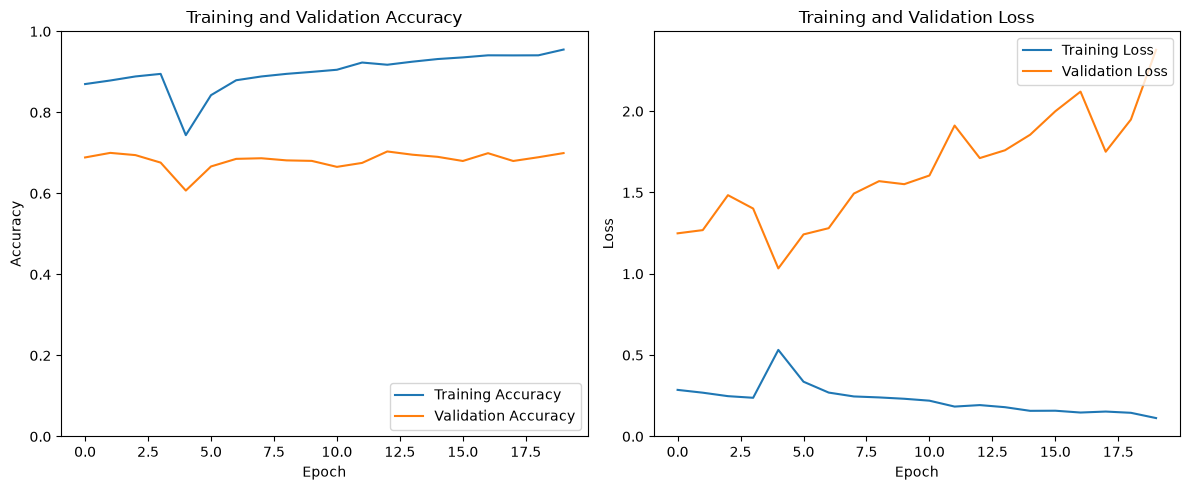


Confusion Matrix (Test Set):
[[1673  827]
 [ 745 1755]]


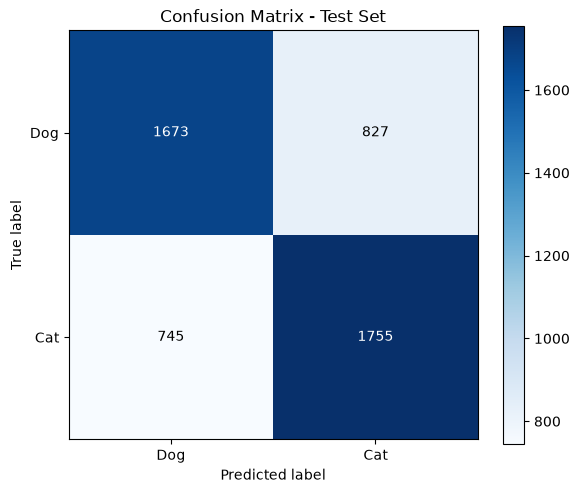

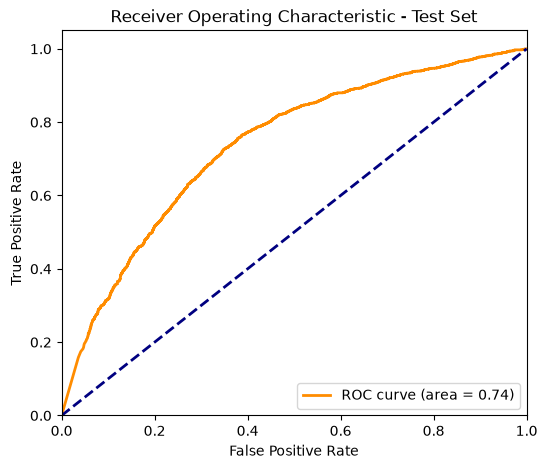

In [52]:
## Model Evaluation and Required Results

# Plot training accuracy and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 1. Training and validation accuracy from the final epoch
# ------------------------------------------------------------
training_accuracy = history.history['accuracy'][-1]
validation_accuracy = history.history['val_accuracy'][-1]


# ------------------------------------------------------------
# 2. Test loss and test accuracy on completely unseen data
# ------------------------------------------------------------
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)


# ------------------------------------------------------------
# 3. Test-set predictions
# ------------------------------------------------------------
y_pred_proba = model.predict(
    X_test,
    verbose=0
).ravel()

y_pred = (y_pred_proba >= 0.5).astype(int)


# ------------------------------------------------------------
# 4. Precision, Recall, and F1-score (macro average)
# ------------------------------------------------------------
precision = precision_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average='macro',
    zero_division=0
)
cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix (Test Set):")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation='nearest',
    cmap=plt.cm.Blues
)

plt.title('Confusion Matrix - Test Set')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_test)))

CATEGORIES = ["Dog", "Cat"]

plt.xticks(
    tick_marks,
    CATEGORIES
)

plt.yticks(
    tick_marks,
    CATEGORIES
)

plt.ylabel('True label')
plt.xlabel('Predicted label')

fmt = 'd'
thresh = cm.max() / 2.0

# IMPORTANT: no extra indentation before "for"
for i, j in np.ndindex(cm.shape):
    plt.text(
        j,
        i,
        format(cm[i, j], fmt),
        ha="center",
        va="center",
        color="white" if cm[i, j] > thresh else "black"
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. ROC Curve and AUC - TEST SET ONLY
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_pred_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (area = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--'
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'Receiver Operating Characteristic - Test Set'
)

plt.legend(
    loc="lower right"
)

plt.show()

In [53]:
# ------------------------------------------------------------
# Display the exact values needed for the manual evaluation form
# ------------------------------------------------------------
print("=" * 65)
print("FINAL CNN MODEL EVALUATION")
print("=" * 65)

print(
    f"Training Accuracy:   "
    f"{training_accuracy:.4f} "
    f"({training_accuracy * 100:.2f}%)"
)

print(
    f"Validation Accuracy: "
    f"{validation_accuracy:.4f} "
    f"({validation_accuracy * 100:.2f}%)"
)

print(
    f"Test Accuracy:       "
    f"{test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Test Loss:           "
    f"{test_loss:.4f}"
)

print(
    f"Precision (macro):   "
    f"{precision:.4f} "
    f"({precision * 100:.2f}%)"
)

print(
    f"Recall (macro):      "
    f"{recall:.4f} "
    f"({recall * 100:.2f}%)"
)

print(
    f"F1-score (macro):    "
    f"{f1:.4f} "
    f"({f1 * 100:.2f}%)"
)

print("=" * 65)


FINAL CNN MODEL EVALUATION
Training Accuracy:   0.9551 (95.51%)
Validation Accuracy: 0.6995 (69.95%)
Test Accuracy:       0.6856 (68.56%)
Test Loss:           2.4433
Precision (macro):   0.6858 (68.58%)
Recall (macro):      0.6856 (68.56%)
F1-score (macro):    0.6855 (68.55%)


In [54]:
import tensorflow as tf

# Define the filename for your model
model_filename = 'dog_cat_classifier.keras'

# Save the trained model
model.save(model_filename)
print(f"Model saved to {model_filename}")

# Load the model
loaded_model = tf.keras.models.load_model(model_filename)
print(f"Model loaded from {model_filename}")

# Verify the loaded model using the unseen test set
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f"Loaded model test accuracy: {loaded_test_accuracy*100:.2f}%")
print(f"Loaded model test loss:     {loaded_test_loss:.4f}")


Model saved to dog_cat_classifier.keras
Model loaded from dog_cat_classifier.keras
Loaded model test accuracy: 68.56%
Loaded model test loss:     2.4433


## Prediction Inference

Now that the model is loaded, we can use it to make predictions on new, unseen data. For demonstration purposes, I'll take a few samples from your existing `X` data to illustrate how to get predictions from the `loaded_model`.

Predictions for unseen test samples:
Sample 1: Predicted Class = Cat (Cat probability: 100.00%)
Sample 2: Predicted Class = Cat (Cat probability: 100.00%)
Sample 3: Predicted Class = Dog (Cat probability: 0.00%)
Sample 4: Predicted Class = Dog (Cat probability: 0.01%)
Sample 5: Predicted Class = Cat (Cat probability: 100.00%)


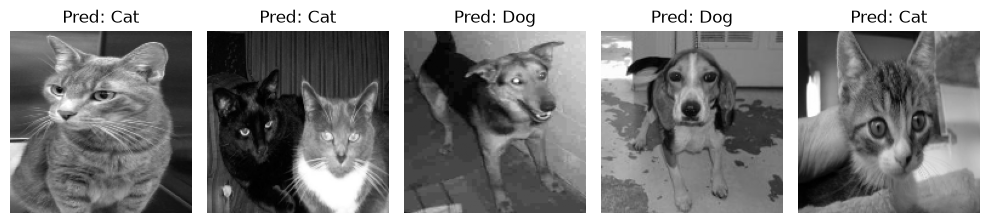

In [55]:
# Select a small subset of the unseen test set for inference
test_samples = X_test[:5]

# Make predictions using the loaded model
inference_predictions = loaded_model.predict(test_samples, verbose=0)

print("Predictions for unseen test samples:")
for i, prediction in enumerate(inference_predictions):
    predicted_class = 'Cat' if prediction[0] > 0.5 else 'Dog'
    probability = prediction[0] * 100
    print(f"Sample {i+1}: Predicted Class = {predicted_class} (Cat probability: {probability:.2f}%)")

# Display the images and predictions
plt.figure(figsize=(10, 4))
for i in range(min(5, len(test_samples))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_samples[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    predicted_class = 'Cat' if inference_predictions[i][0] > 0.5 else 'Dog'
    plt.title(f"Pred: {predicted_class}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [25]:
print("model exists:", "model" in globals())
print("loaded_model exists:", "loaded_model" in globals())
print("history exists:", "history" in globals())
print("X_train exists:", "X_train" in globals())
print("X_test exists:", "X_test" in globals())
print("y_train exists:", "y_train" in globals())
print("y_test exists:", "y_test" in globals())

model exists: True
loaded_model exists: True
history exists: True
X_train exists: True
X_test exists: True
y_train exists: True
y_test exists: True


In [26]:
print("Optimizer:", model.optimizer.__class__.__name__)
print("Learning rate:", model.optimizer.learning_rate.numpy())

Optimizer: Adam
Learning rate: 0.001
